In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from common import get_triads,get_G

## Setup

In [3]:
kmax=30;kmin=6
n=int(kmax)*2+1
idk=(np.array(np.where(np.zeros([n]*2)==0))-kmax).astype(int)
order=lambda x: ((x[0]+kmax)*n+(x[1]+kmax)).astype(int)
rho=lambda x: x**(-7/3)

k,p,q,kmag,pmag,qmag,Gcosrho,Gcosrho_dir=get_G(return_triads=True,kmax=kmax,kmin=kmin,rho=rho)

# ## Gs=[G,Grho,Gcos,Gcosrho]
# ## Gs_dir=[G_dir,Grho_dir,Gcos_dir,Gcosrho_dir]
# k,p,q,kmag,pmag,qmag,Gs,Gs_dir=get_G(return_triads=True,kmax=kmax,kmin=kmin,rho=rho)

In [4]:
def plot_G(G,colorbar=False,small=True):
    if small:
        fig,ax=plt.subplots(1,6,layout='constrained',figsize=(12,6))
    else:
        fig,ax=plt.subplots(2,3,layout='constrained',figsize=(10,6))
    
    points=[np.array([6,0]),np.array([20,0]),np.array([30,0]),np.array([25,4]),np.array([5,5]),np.array([15,15])]
    coords=(idk+kmax).astype(int)
    
    for i in range(len(points)):
        grid=np.zeros([n]*2)
        grid[coords[1],coords[0]]=G[order(points[i])]
        grid[grid==0]=None
        ax.flat[i].set_title(rf'$k=[{points[i][0]}, {points[i][1]}]$')
        im=ax.flat[i].imshow(grid,extent=[-kmax,kmax,-kmax,kmax],origin='lower',cmap='plasma')
        ax.flat[i].plot(points[i][0],points[i][1],'gx',ms=7)
        if colorbar:
            plt.colorbar(im)    
    plt.show()

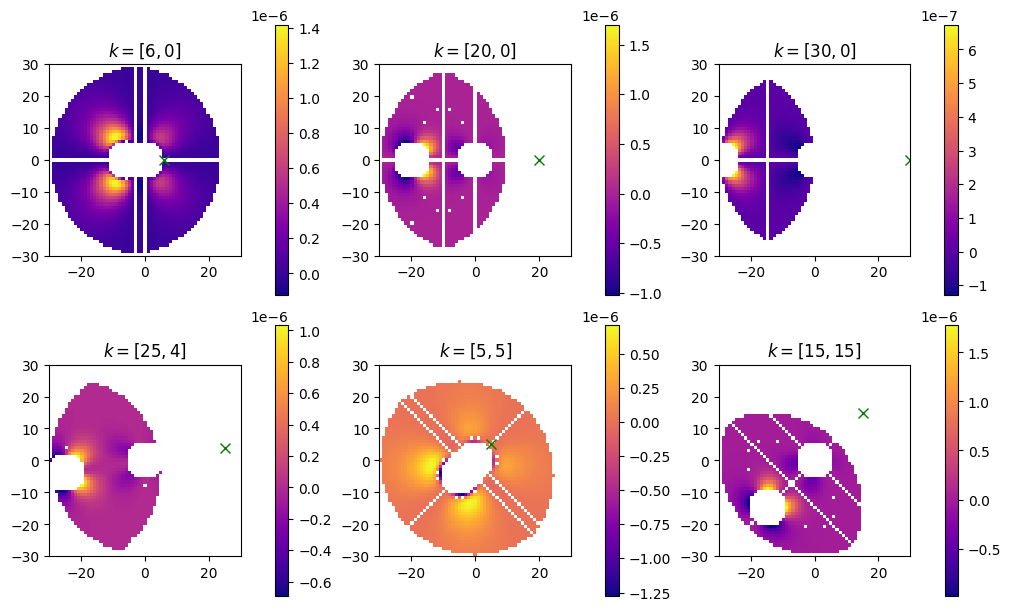

In [88]:
plot_G(Gcosrho_dir,small=False,colorbar=True)
thresh=Gcosrho_dir.copy()

def threshold_testing(thresh):
    deg=(thresh!=0).sum(axis=1)/2
    plot_G(thresh,small=True,colorbar=False)
    
    # # degree heatmap
    # coords=(idk+kmax).astype(int)
    # (thresh!=0).sum(axis=1)
    # grid=np.zeros([n]*2)
    # grid[coords[1],coords[0]]=(thresh!=0).sum(axis=1)/2
    # grid[grid==0]=None
    # plt.imshow(grid,extent=[-kmax,kmax,-kmax,kmax],origin='lower',cmap='plasma')
    # plt.colorbar()
    # plt.show()
    
    fig,ax=plt.subplots(1,2,figsize=(10,3.5),layout='constrained')
    # degree histogram
    ax[0].hist(deg[deg!=0],bins=30)
    ax[0].set_xlabel('Degree');plt.ylabel('Frequency')
    
    # degree plot
    ax[1].plot(np.linalg.norm(idk,axis=0)[deg!=0],deg[deg!=0],'.',ms=1)
    ax[1].grid()
    ax[1].set_xlabel(r'$k$');plt.ylabel('Degree')
    plt.show()

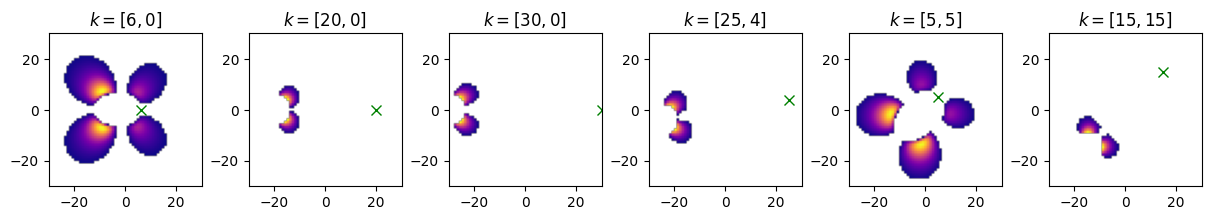

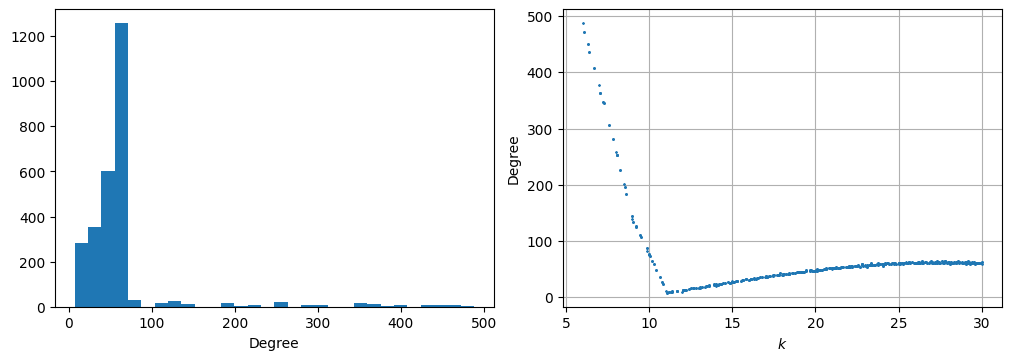

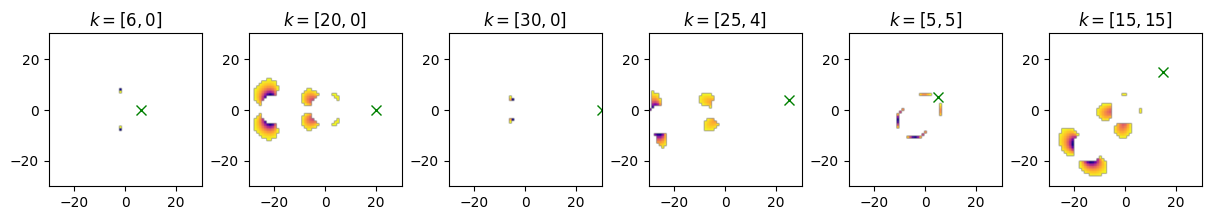

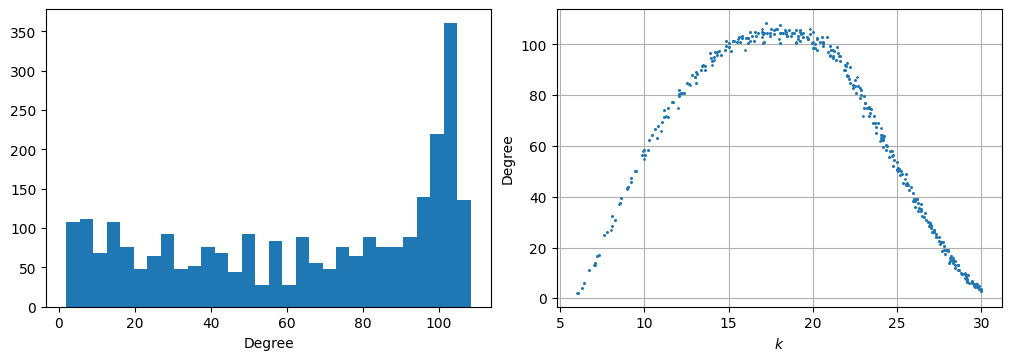

In [94]:
# thresh=Gcosrho_dir.copy()
# thresh[np.abs(thresh)<np.percentile(np.abs(thresh),95)]=0 # increasing this pushes the inflection point to the left
thresh=Gcosrho_dir.copy()
thresh[thresh<np.percentile(thresh,97.5)]=0;threshold_testing(thresh)
thresh=Gcosrho_dir.copy()
thresh[(thresh>np.percentile(thresh,2.5))|(np.sign(thresh)==1)]=0;threshold_testing(thresh)

## Old Code

In [7]:
# path='./data/'
# triads=np.loadtxt(path+'triads.txt')
# k_data=triads[:,[0,1]].T
# p_data=triads[:,[2,3]].T
# q_data=-k_data-p_data

# k_order=order(k_data).argsort();p_order=order(p_data).argsort();q_order=order(q_data).argsort()
# k_data=k_data[:,k_order];p_data=p_data[:,p_order];q_data=q_data[:,q_order]

# kmag_data=np.linalg.norm(k_data,axis=0);pmag_data=np.linalg.norm(p_data,axis=0);qmag_data=np.linalg.norm(q_data,axis=0)

# rhok=np.load(path+'rhok.npy').astype(np.float64)[0,k_order];rhop=np.load(path+'rhop.npy').astype(np.float64)[0,p_order];rhoq=np.load(path+'rhoq.npy').astype(np.float64)[0,q_order]

# all_mag=np.array([kmag_data,pmag_data,qmag_data]).flatten()
# all_rho=np.array([rhok,rhop,rhoq]).flatten()

# # def rho(x,a,b):
# #     return a*(x**b)

# # a,b=curve_fit(rho,all_mag,all_rho)[0]
# # print(f'a = {a}, b = {b}')

# # rhok=rho(kmag,a,b)
# # rhop=rho(pmag,a,b)
# # rhoq=rho(qmag,a,b)

# # plt.plot(kmag,rho(kmag,a,b))
# # plt.plot(kmag_data,rhok,'.',ms=1)
# # plt.plot(pmag_data,rhop,'.',ms=1)
# # plt.plot(qmag_data,rhoq,'.',ms=1)
# # plt.show()
